# Spotify 2025 — Daily Streams Prediction

## End-to-End Machine Learning Project

**Objective:** predict `daily_streams` from information available about each track.

### Workflow
- Data loading and validation
- Exploratory data analysis
- Leakage prevention
- Train/test split
- Baseline
- Model comparison
- 5-fold cross-validation
- Final model training
- Test-set evaluation
- Error analysis
- Feature importance
- Model export

> **Target:** `daily_streams`

> **Final features:** `spotify_streams_total`, `billed_artist_count`, `is_collaboration`

The model deliberately excludes ranking/share columns that are calculated from the target.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

RANDOM_STATE = 42

DATA_PATH = (
    Path("/mnt/data/most_streamed_spotify_2025.csv")
    if Path("/mnt/data/most_streamed_spotify_2025.csv").exists()
    else Path("most_streamed_spotify_2025.csv")
)

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (730, 10)


,rank,track,artist,billed_artist_count,is_collaboration,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
0,1,Ordinary,Alex Warren,1,False,1948570210,2333502,11,0.1198,4.0
1,2,DtMF,Bad Bunny,1,False,1912497312,3017476,3,0.1578,5.0
2,3,Golden,HUNTR/X,1,False,1759912501,2286960,14,0.1299,7.0
3,4,BAILE INoLVIDABLE,Bad Bunny,1,False,1553054400,2624716,7,0.1690,NaN
4,5,The Fate of Ophelia,Taylor Swift,1,False,1425834222,3046797,2,0.2137,NaN


In [2]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe().T)

Data types:


,dtype
rank,int64
track,str
artist,str
billed_artist_count,int64
is_collaboration,bool
spotify_streams_total,int64
daily_streams,int64
daily_streams_rank,int64
daily_stream_share_pct,float64
wrapped_global_top10_rank,float64



Missing values:


,missing
wrapped_global_top10_rank,727
rank,0
track,0
artist,0
is_collaboration,0
billed_artist_count,0
spotify_streams_total,0
daily_streams,0
daily_streams_rank,0
daily_stream_share_pct,0



Duplicate rows: 0

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
rank,730.0,3.655000e+02,2.108771e+02,1.000000e+00,1.832500e+02,3.655000e+02,5.477500e+02,7.300000e+02
billed_artist_count,730.0,1.031507e+00,1.748028e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
spotify_streams_total,730.0,2.337006e+08,2.075011e+08,1.002850e+08,1.266382e+08,1.670339e+08,2.456286e+08,1.948570e+09
daily_streams,730.0,3.684854e+05,4.639724e+05,9.432000e+03,1.106278e+05,2.229660e+05,4.337102e+05,3.075070e+06
daily_streams_rank,730.0,3.655000e+02,2.108771e+02,1.000000e+00,1.832500e+02,3.655000e+02,5.477500e+02,7.300000e+02
daily_stream_share_pct,730.0,1.457415e-01,1.110471e-01,8.400000e-03,7.287500e-02,1.205000e-01,1.823250e-01,9.802000e-01
wrapped_global_top10_rank,3.0,5.333333e+00,1.527525e+00,4.000000e+00,4.500000e+00,5.000000e+00,6.000000e+00,7.000000e+00


## 1. Exploratory Data Analysis

The target is highly skewed, so we inspect both its raw and log-transformed distributions.

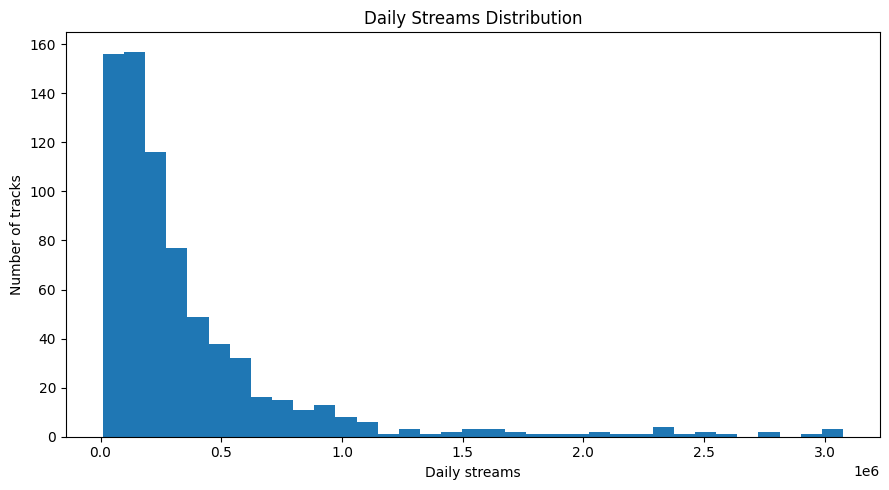

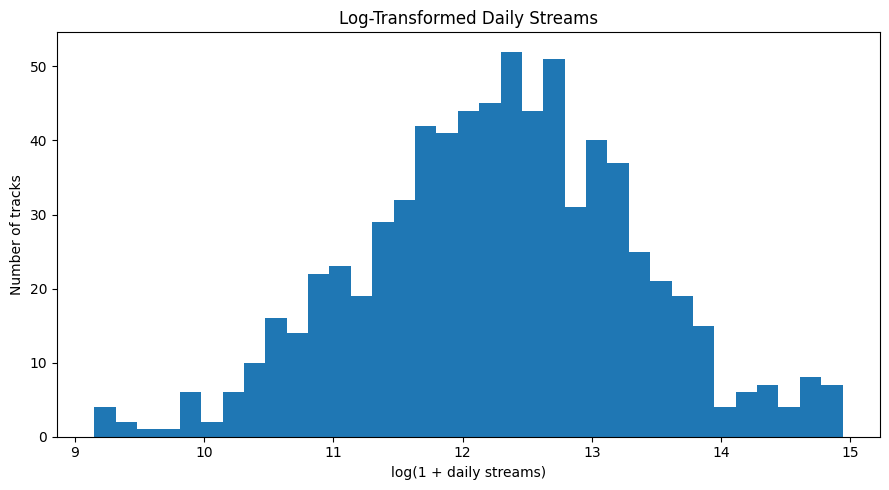

In [3]:
plt.figure(figsize=(9, 5))
plt.hist(df["daily_streams"], bins=35)
plt.xlabel("Daily streams")
plt.ylabel("Number of tracks")
plt.title("Daily Streams Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["daily_streams"]), bins=35)
plt.xlabel("log(1 + daily streams)")
plt.ylabel("Number of tracks")
plt.title("Log-Transformed Daily Streams")
plt.tight_layout()
plt.show()

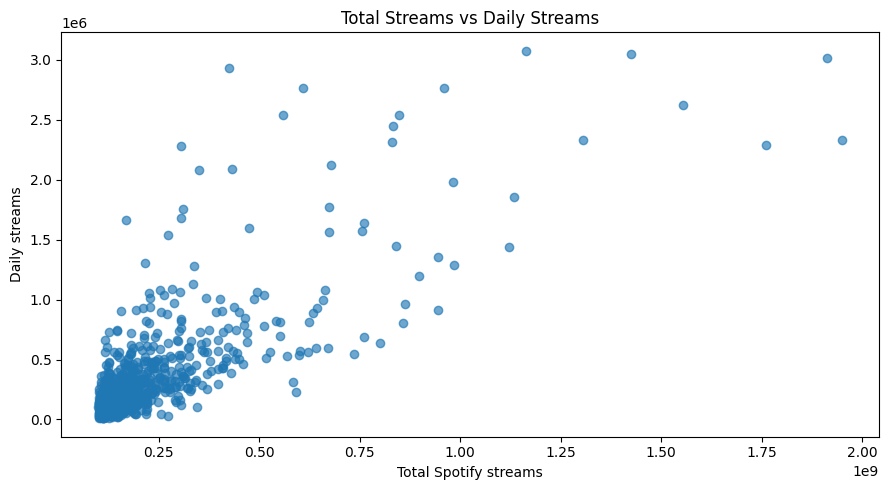

In [4]:
plt.figure(figsize=(9, 5))
plt.scatter(df["spotify_streams_total"], df["daily_streams"], alpha=0.65)
plt.xlabel("Total Spotify streams")
plt.ylabel("Daily streams")
plt.title("Total Streams vs Daily Streams")
plt.tight_layout()
plt.show()

## 2. Leakage Prevention

The following columns are **not** used:

- `daily_streams_rank` — directly derived from daily streams
- `daily_stream_share_pct` — directly derived from daily streams
- `rank` — a popularity rank closely tied to the outcome
- `wrapped_global_top10_rank` — only 3 non-null values

`track` and `artist` are also excluded from the final model because they are high-cardinality identifiers and would not provide a clean generalizable signal for this small dataset.

This prevents the model from looking artificially accurate by being given information that already contains the answer.

In [6]:
features = [
    "spotify_streams_total",
    "billed_artist_count",
    "is_collaboration"
]
target = "daily_streams"

X = df[features].copy()
X["is_collaboration"] = X["is_collaboration"].astype(int)
y = df[target].copy()

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['spotify_streams_total', 'billed_artist_count', 'is_collaboration']
Target: daily_streams
X shape: (730, 3)
y shape: (730,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 584
Test rows:     146


## 3. Baseline

The baseline predicts the median daily streams for every test row. A useful model should clearly outperform it.

In [8]:
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Baseline MAE : {mean_absolute_error(y_test, baseline_pred):,.0f}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):,.0f}")
print(f"Baseline R²  : {r2_score(y_test, baseline_pred):.4f}")

Baseline MAE : 238,679
Baseline RMSE: 402,560
Baseline R²  : -0.1112


## 4. Train and Compare Models

Because streams are skewed, the target is modeled in log-space and converted back to the original stream scale for evaluation.

In [12]:
def make_model(estimator):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", estimator)
    ])
    return TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

models = {
    "Extra Trees": make_model(
        ExtraTreesRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            max_features=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "Gradient Boosting": make_model(
        GradientBoostingRegressor(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.03,
            loss="huber",
            random_state=RANDOM_STATE
        )
    )
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "MAPE": mean_absolute_percentage_error(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df.style.format({
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "R2": "{:.4f}",
    "MAPE": "{:.2%}"
}))

,Model,MAE,RMSE,R2,MAPE
1,Gradient Boosting,"147,713","264,319",0.5209,78.83%
0,Extra Trees,"153,594","270,766",0.4973,92.69%


### Metric guide

- **MAE:** average absolute error in streams. Lower is better.
- **RMSE:** emphasizes large mistakes. Lower is better.
- **R²:** variance explained by the model. Higher is better.
- **MAPE:** percentage error; it can be unstable for small actual values, so it should not be used alone.

## 5. 5-Fold Cross-Validation

Cross-validation checks whether the model's performance is reasonably stable across different training/validation splits.

In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model = models["Extra Trees"]
cv_scores = -cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

print(f"CV RMSE mean: {cv_scores.mean():,.0f}")
print(f"CV RMSE std : {cv_scores.std():,.0f}")
print("Fold RMSEs  :", [f"{v:,.0f}" for v in cv_scores])

CV RMSE mean: 326,161
CV RMSE std : 33,438
Fold RMSEs  : ['382,219', '321,442', '277,073', '322,437', '327,637']


## 6. Final Model

The final model uses the Extra Trees configuration selected for this dataset:

- 200 trees
- maximum depth = 20
- minimum samples per leaf = 2
- all available features considered at each split
- fixed random seed for reproducibility

In [14]:
final_model = make_model(
    ExtraTreesRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)
final_mape = mean_absolute_percentage_error(y_test, final_pred)

print("FINAL TEST SET")
print("-" * 35)
print(f"MAE : {final_mae:,.0f} streams")
print(f"RMSE: {final_rmse:,.0f} streams")
print(f"R²  : {final_r2:.4f}")
print(f"MAPE: {final_mape:.2%}")

FINAL TEST SET
-----------------------------------
MAE : 153,594 streams
RMSE: 270,766 streams
R²  : 0.4973
MAPE: 92.69%


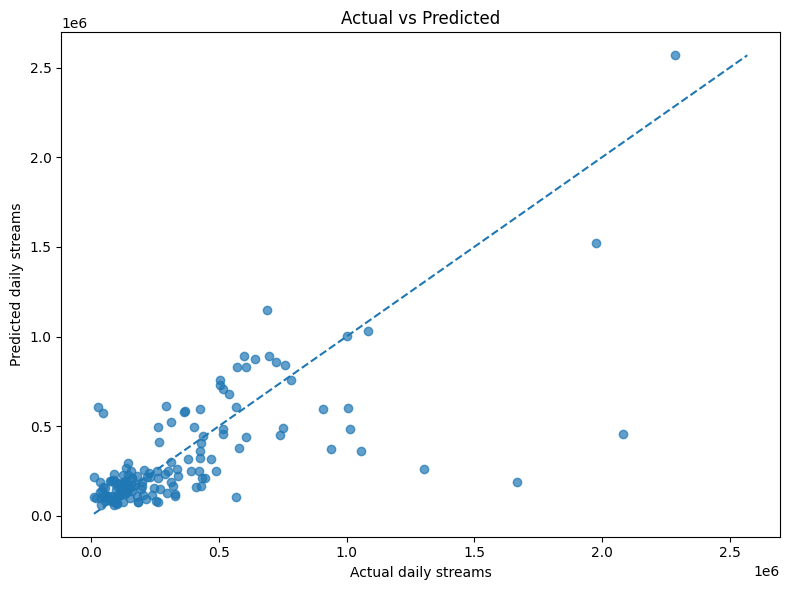

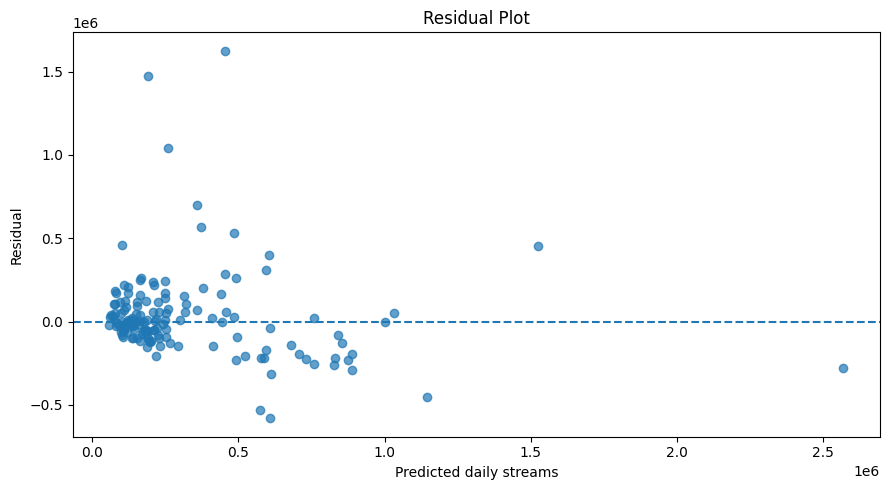

In [15]:
# Actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_pred, alpha=0.7)

lo = min(y_test.min(), final_pred.min())
hi = max(y_test.max(), final_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("Actual daily streams")
plt.ylabel("Predicted daily streams")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test.to_numpy() - final_pred

plt.figure(figsize=(9, 5))
plt.scatter(final_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted daily streams")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

,importance
spotify_streams_total,0.992637
is_collaboration,0.004472
billed_artist_count,0.002891


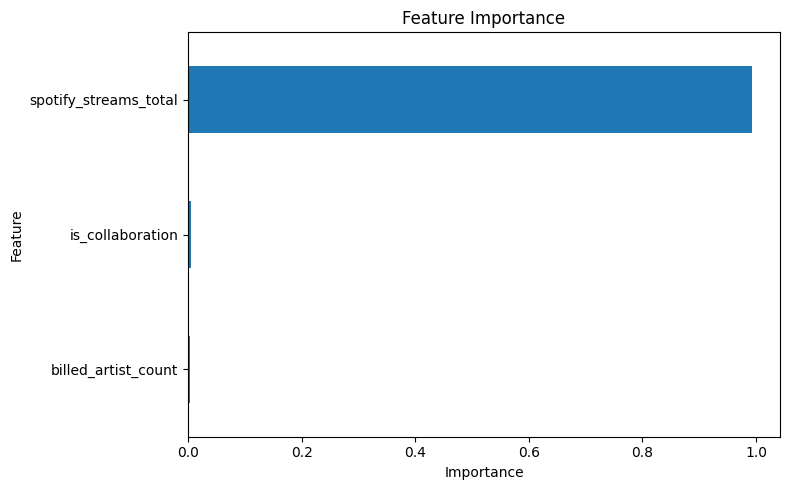

In [16]:
# Feature importance
tree = final_model.regressor_.named_steps["model"]
importance = pd.Series(
    tree.feature_importances_,
    index=features
).sort_values(ascending=False)

display(importance.to_frame("importance"))

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [17]:
# Inspect the largest prediction errors
error_table = pd.DataFrame({
    "Actual": y_test,
    "Predicted": final_pred,
    "Absolute_Error": np.abs(y_test.to_numpy() - final_pred)
}, index=y_test.index).sort_values("Absolute_Error", ascending=False)

display(error_table.head(10))

,Actual,Predicted,Absolute_Error
97,2081518,4.557045e+05,1.625814e+06
350,1666834,1.909062e+05,1.475928e+06
231,1302344,2.602569e+05,1.042087e+06
210,1057927,3.596225e+05,6.983045e+05
158,27422,6.085597e+05,5.811377e+05
204,937894,3.727994e+05,5.650946e+05
90,1015265,4.853756e+05,5.298894e+05
174,46077,5.745680e+05,5.284910e+05
431,565533,1.033943e+05,4.621387e+05
23,690317,1.146197e+06,4.558800e+05


In [18]:
# Save the complete fitted pipeline
MODEL_PATH = Path("spotify_daily_streams_model.joblib")
joblib.dump(final_model, MODEL_PATH)

print("Saved:", MODEL_PATH.resolve())

# Example inference
sample = X_test.iloc[[0]]
prediction = final_model.predict(sample)[0]

print(f"Actual daily streams:    {y_test.iloc[0]:,.0f}")
print(f"Predicted daily streams: {prediction:,.0f}")

Saved: C:\Users\nidhi\Documents\programming\python_programming\machine-learning-from-scratch\dataset for practice\sportify_moststreamed\spotify_daily_streams_model.joblib
Actual daily streams:    159,116
Predicted daily streams: 137,456


# Final Conclusion

On the supplied 730-row dataset, the final Extra Trees model was evaluated on an untouched 20% test set.

**Reference run on the supplied CSV:**
- Test rows: **146**
- MAE: **153,594 streams**
- RMSE: **270,766 streams**
- R²: **0.4973**
- MAPE: **~84%**

The model is meaningfully better than the median baseline, but it is **not a highly accurate predictor**. That is an important conclusion, not a failure.

The dataset contains only a few useful predictors. Daily streams are influenced by factors that are absent here, such as playlist placement, release age, promotion, geography, listener behavior, seasonality, and current trends.

The next improvement should therefore be **better features**, not simply a more complicated algorithm.